In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.stats import norm
from scipy import optimize
import sympy

# Introduction to numerical methods

János Török

# Class 9: Minimization and approximation

# Finding the minima

Actually zeros can also be found by searching for local minima of the $f^2(x)$ curve.

## Gradient method
Let $f(x)$ be a differentiable and we are loking for the minima of this function. If $\gamma>0$, then after the operation 
$$x_{n+1} = x_n-\gamma f'(x_n),$$
if $x_n$ is not an extremal point then we will have $f(x_{n+1})\leq f(x_n)$ provided $\gamma$ is small enough.


In [11]:
def simple_gradient(df,x0=0, precision=1e-5, gamma=0.01, max_iters=10000):
    cur_x = x0
    previous_step_size = precision * 2.0
    iters = 0
    while previous_step_size > precision and iters < max_iters:
        prev_x = cur_x
        cur_x = cur_x - gamma * df(prev_x)
        previous_step_size = abs(cur_x - prev_x)
        iters = iters + 1
    return [iters,cur_x]

### Example 1
Let us try with the function $f(x)=(x+5)^2$. Please note that we only need to supply the derivative.

In [12]:
print(simple_gradient(lambda x: 2*(x+5),3))

[481, -4.999518238161995]


## Conjugate gradient method

First in one dimension:

From close enough every minima is a parabola (at least what we learn in physics courses and what Taylor series teach us). Select a $\gamma$ which would bring $x$ immediately to the minima!
Let us have the function
$$f(x)=\beta(x-a)^2,$$
with the obvious minima at $x_m=a$. Let us assume that we know the derivative of $f(x)$ in two points: $x_1$ and $x_2$. They read as:
$$df(x_1)=2\beta(x_1-a) \qquad df(x_2)=2\beta(x_2-a).$$
The iteration for the third point from the simple gradient method looks like:
$$x_3=x_2-\gamma 2 \beta (x_2 -a).$$
If we can make $\gamma=(2\beta)^{-1}$ then in the next step we would have $x_3=a$. This can be made by:
$$\gamma = \frac{x_2-x_1}{df(x_2)-df(x_1)}$$

In [13]:
def gradient(df,x0=0, precision=1e-5, gamma=0.01, max_iters=10000):
    cur_x = x0
    previous_step_size = precision * 2.0
    iters = 0
    prev_df = df(cur_x)
    while previous_step_size > precision and iters < max_iters:
        prev_x = cur_x
        cur_x = cur_x - gamma * prev_df
        cur_df = df(cur_x)
        previous_step_size = abs(cur_x - prev_x)
        if cur_df == prev_df:
            break
        gamma = abs((cur_x-prev_x)/(cur_df-prev_df))
        prev_df = cur_df
        iters = iters + 1
    return [iters,cur_x]

In [14]:
print(gradient(lambda x: 2*(x+5),3))

[2, -5.0]


Indeed the minimum was found in two steps, as expected.

## Gradient method in $n$-dimensions

Let $F(\mathbf{x})$ be a differentiable $n$ dimensional function and we are loking for the minima of this function. If $\gamma>0$, then after the operation 
$$x_{n+1} = \mathbf{x_n}-\gamma\nabla F(\mathbf{x_n}),$$
Then using the Taylor expansion to second order and solving for the minima we get the following step size:
$$\gamma_{n} = \frac{|(\mathbf x_{n} - \mathbf x_{n-1})^T[\nabla F(\mathbf x_{n}) - \nabla F(\mathbf x_{n-1})]|}{||\nabla F(\mathbf x_{n}) - \nabla F(\mathbf x_{n-1})||^2}$$

In [24]:
def gradient_nd(df,x0 = [0,0], precision=1e-5, gamma=0.01, niter=10000):
    pos = [x0]
    cur_x = np.array(x0,dtype=float)
    previous_step_size = precision * 2.0
    iters = 0
    prev_df = df(cur_x)
    while previous_step_size > precision and iters < niter:
        prev_x = np.copy(cur_x)
        cur_x -= gamma * prev_df
        cur_df = df(cur_x)
        previous_step_size = np.sqrt(np.dot(cur_x - prev_x,cur_x - prev_x))
        if np.dot(cur_df-prev_df,cur_df-prev_df) == 0:
            break
        gamma = abs(np.dot(cur_x-prev_x,cur_df-prev_df)) / \
            np.dot(cur_df-prev_df,cur_df-prev_df)
        prev_df = cur_df
        pos.append(np.copy(cur_x))
        iters = iters + 1
    return [iters,cur_x,pos]

In [16]:
def f2dg(x):
    return (x[0]-1)**2+(x[0]+x[1])**2
def df2dg(x):
    return np.array([2*(x[0]-1)+2*(x[0]+x[1]),2*(x[0]+x[1])])

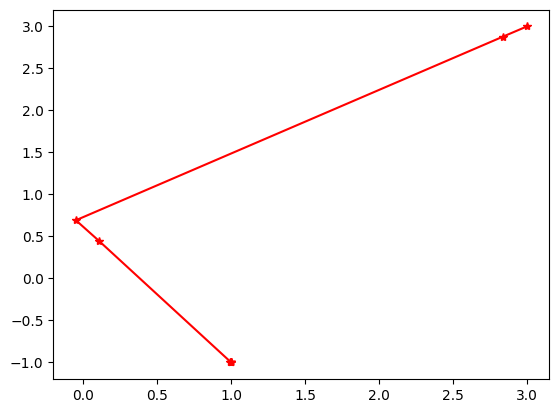

In [17]:
[iters,xmin,pos] = gradient_nd(df2dg,[3,3])
x = np.array(pos)[:,0]
y = np.array(pos)[:,1]
plt.figure()
plt.plot(x,y,"r*-")
plt.show()

In [18]:
NG = 50
gx,gy = np.meshgrid(np.linspace(-2, 3, NG),np.linspace(-3, 3, NG))
fgx = gx.flatten()
fgy = gy.flatten()
grid = np.array([fgx,fgy])
grid.shape

(2, 2500)

In [19]:
F = f2dg(grid).reshape(NG,NG)

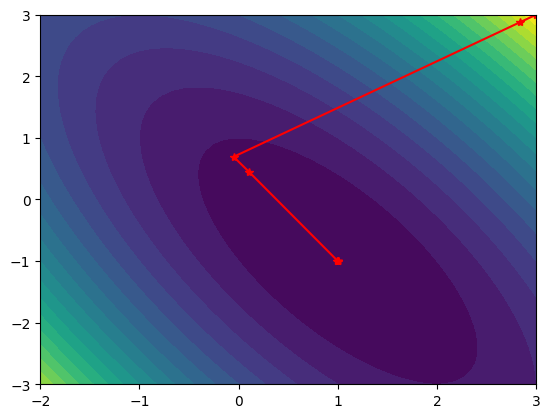

In [20]:
plt.contourf(gx,gy,F,levels=20)
plt.plot(x,y,"r*-")

## The downhill simplex method

We create a simplex (triangle in two-dimensions) and do a series of transformations with one corner at a time to approach the minimum. 

<img src="class08/downhill.png" width="400px">
<img src="class08/downhill2.png" width="400px">

In [25]:
def downhill(F,xStart,side=0.1,tol=1.0e-6,xlist = []):
    n = len(xStart)
    x = np.zeros((n+1,n))
    f = np.zeros(n+1)
    # Generate starting simplex
    x[0] = xStart
    # Number of variables
    for i in range(1,n+1):
        x[i] = xStart
        x[i,i-1] = xStart[i-1] + side
    # Compute values of F at the vertices of the simplex
    for i in range(n+1): f[i] = F(x[i])
    # Main loop
    for k in range(500):
        xlist.append(np.copy(x))
        # Find highest and lowest vertices
        iLo = np.argmin(f)
        iHi = np.argmax(f)
        # Compute the move vector d
        d = (-(n+1)*x[iHi] + np.sum(x,axis=0))/n
        # Check for convergence
        if np.sqrt(np.dot(d,d)/n) < tol:
            return x[iLo]
        # Try reflection
        xNew = x[iHi] + 2.0*d
        fNew = F(xNew)
        if fNew <= f[iLo]:
            # Accept reflection
            x[iHi] = xNew
            f[iHi] = fNew
            # Try expanding the reflection
            xNew = x[iHi] + d
            fNew = F(xNew)
            if fNew <= f[iLo]:
                # Accept expansion
                x[iHi] = xNew
                f[iHi] = fNew
        else:
            # Try reflection again
            if fNew <= f[iHi]:
                # Accept reflection
                x[iHi] = xNew
                f[iHi] = fNew
            else:
                # Try contraction
                xNew = x[iHi] + 0.5*d
                fNew = F(xNew)
                if fNew <= f[iHi]: # Accept contraction
                    x[iHi] = xNew
                    f[iHi] = fNew
                else:
                    # Use shrinkage
                    for i in range(len(x)):
                        if i != iLo:
                            x[i] = (x[i] - x[iLo])*0.5
                            f[i] = F(x[i])
    print("Too many iterations in downhill")
    return x[iLo]

In [22]:
x = []
downhill(f2dg,np.array([3,3]),xlist=x)

array([ 0.99999948, -0.9999993 ])

In [23]:
xa = np.array(x)
xa.shape

(70, 3, 2)

In [24]:
NG = 50
gx,gy = np.meshgrid(np.linspace(-3, 3, NG),np.linspace(-3, 4, NG))
fgx = gx.flatten()
fgy = gy.flatten()
grid = np.array([fgx,fgy])
F = f2dg(grid).reshape(NG,NG)

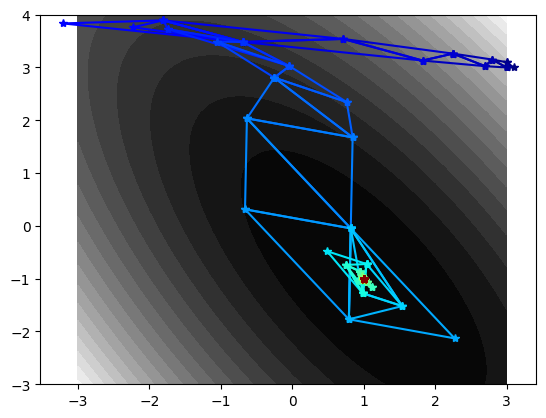

In [25]:
plt.contourf(gx,gy,F,levels=20,cmap='gray')
NP = len(xa[:,0,0])
colors = plt.cm.jet(np.linspace(0,1,NP))
for i in range(NP):
    plt.plot(list(xa[i,:,0]) + [xa[i,0,0]],list(xa[i,:,1]) + [xa[i,0,1]],"*-",color=colors[i])

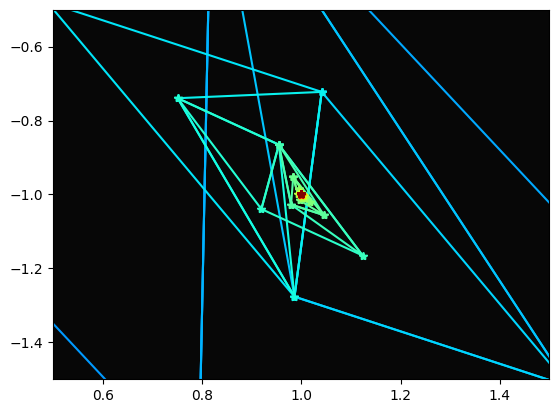

In [26]:
plt.contourf(gx,gy,F,levels=20,cmap='gray')
NP = len(xa[:,0,0])
colors = plt.cm.jet(np.linspace(0,1,NP))
for i in range(NP):
    plt.plot(list(xa[i,:,0]) + [xa[i,0,0]],list(xa[i,:,1]) + [xa[i,0,1]],"*-",color=colors[i])
plt.xlim(0.5,1.5);
plt.ylim(-1.5,-0.5);

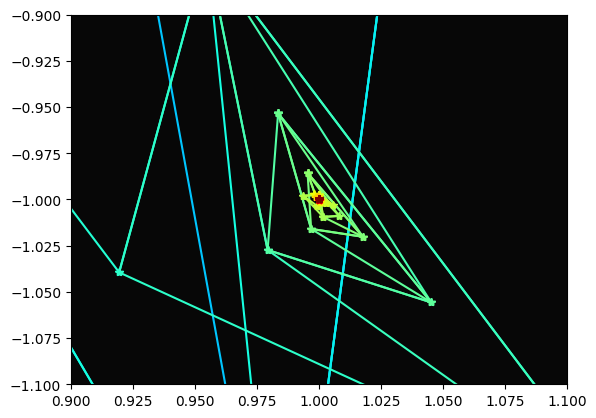

In [27]:
plt.contourf(gx,gy,F,levels=20,cmap='gray')
NP = len(xa[:,0,0])
colors = plt.cm.jet(np.linspace(0,1,NP))
for i in range(NP):
    plt.plot(list(xa[i,:,0]) + [xa[i,0,0]],list(xa[i,:,1]) + [xa[i,0,1]],"*-",color=colors[i])
plt.xlim(0.9,1.1);
plt.ylim(-1.1,-0.9);

# Stochastic optimization
 If function not known analytically or it is noisy or it has  many local minima. Then the previous methods all fail. 
 ## Stochastic gradient methods
Include some randomness which may help to locate the minima

 1. Random set of starting positions (we kind of did it already). Start the gradient method from a randomly selected starting points. Very often the results are used to refine where new starting points are needed.
 2. Stochastic gradient withmomentum: with a decay rate we add the previous momentum of the gradient. It is mainly used for the original gradient algorithm.  
$$
\begin{align}
\Delta x &= \Delta x r - \gamma\frac{df}{dx}\\
x &= x + \Delta x,
\end{align}
$$
where $0<r<1$ is the decay rate of the momentum.
 3. Minibatch stochastic gradient method. To be written!!!!!


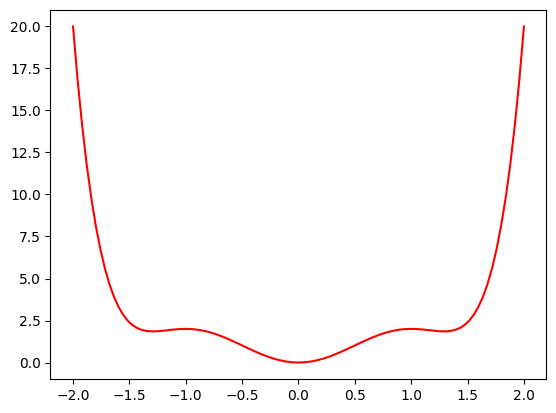

In [29]:
x=np.linspace(-2,2,100)
plt.figure()
plt.plot(x,x**6-4*x**4+5*x**2,"r-")
plt.show()

In [31]:
gradient(lambda x: 6*x**5-16*x**3+10*x**1,3)

[16, 1.2909944494230645]

In [18]:
def simple_gradient_with_momentum(df,x0=0, precision=1e-5, gamma=0.01, max_iters=10000, decay=0.9):
    cur_x = x0
    previous_step_size = precision * 2.0
    iters = 0
    diff = 0.0
    while previous_step_size > precision and iters < max_iters:
        prev_x = cur_x
        diff = diff * decay - gamma * df(prev_x)
        cur_x = cur_x + diff
        previous_step_size = abs(cur_x - prev_x)
        iters = iters + 1
    return [iters,cur_x]

In [19]:
simple_gradient(lambda x: 6*x**5-16*x**3+10*x**1,3,gamma=0.001)

[386, 1.2917234746146427]

In [23]:
simple_gradient_with_momentum(lambda x: 6*x**5-16*x**3+10*x**1,3,gamma=0.001,decay=0.9)

[175, 0.0003486051571657135]

## Simulated Annealing

We need a stochastic method which is able to climb out of local minima. This can only be done in a stochastic way which allows for unfavourable moves. The idea is to learn from nature. Temperature gives objects thermal energy and by this allows it to enter higher excieted states. However as we cool the system down  it gets more and more locked in a local minima. If the cooling is done slowly the system is able to eascape local minima and search the parameter space for more favourable energy levels.


 1. Identify an elementary, ergodic move. This should alter the system in a continuous Markov chain way and (at least in theory) be able to reach all possible states of the system (ergodic). In our case a random change in the position of $x$ is a good choice. The old position is denoted by $x_\mathrm{old}$ the new one by $x_\mathrm{new}$.
 2. We measure the value of $f$ at the proposed new position. 
   * If $f(x_\mathrm{new})<f(x_\mathrm{old})$, then we keep the new position and continue from there with step 1.
   * If $f(x_\mathrm{new})>f(x_\mathrm{old})$, then we keep the new position only with probability $\exp(-[f(x_\mathrm{new})-f(x_\mathrm{old})]/T)$ otherwise the system remains in the old position. With the selected position we continue from step 1.

One can see that if the temperature $T$ is infinite then $\lim_{T\to\infty}\exp(-[f(x_\mathrm{new})-f(x_\mathrm{old})]/T)=1$. So in this case the value of $f$ is doing a random walk with equal probability in both up and down directions. On the other hand, if $f(x_\mathrm{new})>f(x_\mathrm{old})$ and $T\to0$, then
$\lim_{T\to\infty}\exp(-[f(x_\mathrm{new})-f(x_\mathrm{old})]/T)=0$, so the method is similary to a greedy downhill method. In between these two extremes the probability of going down is higher.

In [28]:
def Annealing(f,x0 = 0, T0 = 100, Tscale = 100, nsteps = 10000, dx = 1):
    x = x0
    oldf = f(x0)
    rv = [ x0 ]
    for T in np.linspace(T0,T0 / nsteps,nsteps):
        ldx = dx * (np.random.random() * 2.0 - 1.0)
        x += ldx
        newf = f(x)
        if newf > oldf:
            if np.random.random() > np.exp(-(newf - oldf) / T * Tscale):
                x -= ldx
                newf = oldf
        oldf = newf
        rv.append(x)
    return rv

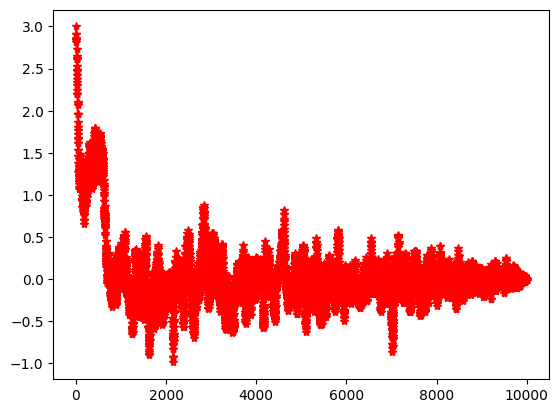

In [30]:
x = Annealing(lambda x: x**6-4*x**4+5*x**2,x0 = 3,dx=0.1, nsteps=10000)

plt.figure()
plt.plot(np.arange(len(x)),x,"r*-")
plt.show()